## CMIP6 Autoencoder - Data Exploration
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

Information on CMIP data

### Links
* https://wcrp-cmip.org/cmip-phases/cmip6/
* https://help.ceda.ac.uk/article/4801-cmip6-data 

### Prerequisites 
what background information is needed to go through the notebook


### Learning outcomes from completing the notebook

## Tutorial 
a balance of explanation and activity



In [1]:
import datetime
import pathlib

In [2]:
import xarray

In [3]:
cmip6_root_dir = pathlib.Path('/badc/cmip6/data/CMIP6')
print(cmip6_root_dir.is_dir())
cmip6_root_dir

True


PosixPath('/badc/cmip6/data/CMIP6')

In [4]:
mip = 'CMIP'
institution = 'MOHC'
model_name = 'HadGEM3-GC31-LL'
simulation = 'historical'
realisation = 'r11i1p1f3'
data_stream = 'Amon'
current_var = 'ta'


In [5]:
sim_realisation_dir = cmip6_root_dir / mip / institution / model_name / simulation / realisation
print(sim_realisation_dir.is_dir())
sim_realisation_dir

True


PosixPath('/badc/cmip6/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/historical/r11i1p1f3')

In [6]:
cmip6_fname_template = '{var}_{stream}_{model}_{simulation}_{realisation}_gn_{start}-{end}.nc'
  # ta_Amon_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_185001-194912.nc 	 ../files/d20230516/ta_Amon_HadGEM3-

In [7]:
var_dir = sim_realisation_dir / data_stream / current_var / 'gn' / 'latest'
print(var_dir.is_dir())
var_dir

True


PosixPath('/badc/cmip6/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/historical/r11i1p1f3/Amon/ta/gn/latest')

In [8]:
start_dt = datetime.datetime(1850,1,1,0,0)
start_str = f'{start_dt.year:04d}{start_dt.month:02d}'
end_dt = datetime.datetime(1949,12,1,0,0)
end_str = f'{end_dt.year:04d}{end_dt.month:02d}'

In [9]:
select_path = var_dir / cmip6_fname_template.format(var=current_var,
                                                    stream=data_stream,
                                                    model=model_name,
                                                    simulation=simulation,
                                                    realisation=realisation,
                                                    start=start_str,
                                                    end=end_str,
                                                   )
cmip_ta_ds = xarray.open_dataset(select_path)

In [18]:
cmip_ta_ds

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 1200, bnds: 2, lat: 144, lon: 192, plev: 19)
Coordinates:
  * time       (time) object 10kB 1850-01-16 00:00:00 ... 1949-12-16 00:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 19kB 1850-01-01 00:00:00 ... 1950-01-01 00...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    ta         (time, plev, lat, lon) float32 3GB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  3600.0
    creation_date:          2023-05-16T11:26:50Z
    ...                     ...
    variable_id:            ta
    variable_name:          ta
    variant_label:          r11i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.7.1
    tracking_id:            hdl:21.14100/0f1a2be5-d78d-46c9-8b4d-ada0cd2be679

In [19]:
cmip_ta_ds['plev']

<xarray.DataArray 'plev' (plev: 19)> Size: 152B
array([100000.,  92500.,  85000.,  70000.,  60000.,  50000.,  40000.,  30000.,
        25000.,  20000.,  15000.,  10000.,   7000.,   5000.,   3000.,   2000.,
         1000.,    500.,    100.])
Coordinates:
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
Attributes:
    units:          Pa
    axis:           Z
    positive:       down
    long_name:      pressure
    standard_name:  air_pressure

In [11]:
import iris
import iris.plot

/home/users/shaddad/mohc_shared/users/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/iris/fileformats/cf.py:934: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'ta'
  warnings.warn(
/home/users/shaddad/mohc_shared/users/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/users/shaddad/mohc_shared/users/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


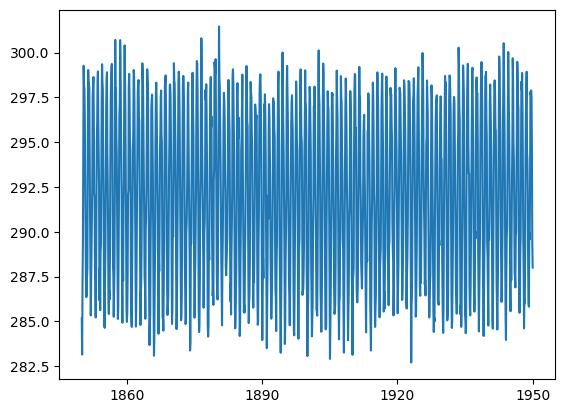

In [12]:
iris.plot.plot(iris.load_cube(select_path).extract(iris.Constraint(
    latitude=lambda c1: 22 <= c1 < 34,
    longitude=lambda c1: 15 <= c1 < 35,
    air_pressure=1e5,
)).collapsed(['latitude','longitude'], iris.analysis.MEAN))



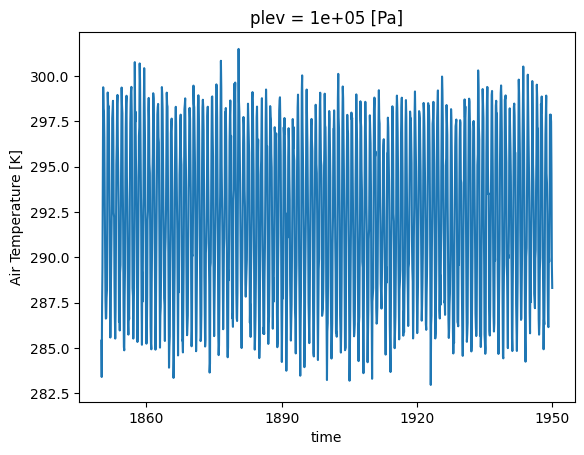

In [13]:
cmip_ta_ds.loc[{'plev': 1e5, 'lat': slice(22,34), 'lon': slice(15,35)}].mean(['lat','lon'])['ta'].plot()

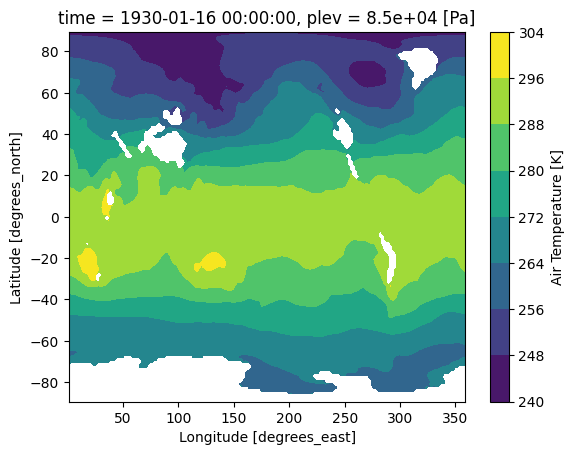

In [24]:
cmip_ta_ds['ta'].loc[{'time':slice('1930-01-01','1930-02-01'), 'plev':85000}][0].plot.contourf()

## Exercises
for students to try that do not have solutions but maybe have an answer or benchmark to facilitate understanding


### Next steps or potential follow on material



###  Exmaples of Use


### Data statement
###     References
